In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
from glob import glob
from pathlib import Path
from natsort import natsorted 
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2
from upsetplot import from_memberships, UpSet
from adjustText import adjust_text  # 用于自动调整标注位置
import warnings
from scipy.stats import norm
from upsetplot import UpSet
import matplotlib as mpl
import matplotlib
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.stats.multitest import multipletests
import sqlite3
%matplotlib inline
from matplotlib.lines import Line2D


matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
def normalize_feature_id(qtl_type, value):
    raw = str(value).strip()
    if not raw or raw.lower() == "nan":
        return None
    if qtl_type == "sQTL":
        return raw.split(":")[-1]
    if qtl_type in {"eeQTL", "enQTL", "isoQTL"}:
        return raw.split(":")[0]
    if qtl_type == "3aQTL":
        parts = raw.split("|")
        return parts[1] if len(parts) > 1 else raw
    if qtl_type in {"eQTL", "stQTL"}:
        return raw
    return raw 

In [5]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftis = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/00.metadata/tissue.order",sep="\t")

In [6]:
color_dict = {
    'eQTL': '#FF5733',
    'eeQTL': '#FFC300',
    'isoQTL': '#FF8D1A',
    'enQTL': '#CD853F',
    'sQTL': '#55A868',
    'stQTL': '#3A5FCD',
    '3aQTL': '#984EA3',
    'Fine-mapped eQTL': '#FF5733',
    'Fine-mapped eeQTL': '#FFC300',
    'Fine-mapped isoQTL': '#FF8D1A',
    'Fine-mapped enQTL': '#CD853F',
    'Fine-mapped sQTL': '#55A868',
    'Fine-mapped stQTL': '#3A5FCD',
    'Fine-mapped 3aQTL': '#984EA3'
}

# Fig. 7a

In [479]:
def remove_outliers(df, col, factor=1.5):
    """使用 IQR 方法去除指定列的极端值"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# 读取数据
herit_wide = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/03.QTL/herit_wide.csv")
herit_wide["QTL_Type"] = herit_wide.iloc[:, 0].str.split(".", n=1).str[-1]
positive_df = herit_wide[(herit_wide["Heritability_QTL"] > 0) & (herit_wide["Heritability_Matched"] > 0)].copy()
filtered_df = pd.concat([remove_outliers(remove_outliers(group, "SE_QTL", factor=1.5), "SE_Matched", factor=1.5) for _, group in positive_df.groupby("QTL_Type")], ignore_index=True)
filtered_df[['Heritability_QTL', 'Heritability_Matched']].mean()

Heritability_QTL        0.025663
Heritability_Matched    0.005844
dtype: float64

In [495]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_rel


all_data = []
pval_annotations = []

for qtl_type in filtered_df["QTL_Type"].unique():
    df_sub = filtered_df[filtered_df["QTL_Type"] == qtl_type].copy()
    df_sub["Trait_Tissue"] = df_sub["Trait"] + "_" + df_sub["Tissue"]

    # 配对 t 检验
    t_stat, p_value = ttest_rel(df_sub["Heritability_QTL"], df_sub["Heritability_Matched"])
    pval_annotations.append((qtl_type, p_value))

    # 转长格式
    df_long = pd.melt(df_sub, id_vars=["Trait_Tissue"], value_vars=["Heritability_QTL", "Heritability_Matched"],
                      var_name="Type", value_name="Heritability")
    df_long["Type"] = df_long["Type"].replace({"Heritability_QTL": "QTL", "Heritability_Matched": "Matched"})
    df_long["Group"] = qtl_type + "_" + df_long["Type"]

    df_filtered = remove_outliers(df_long, "Heritability", factor=2.5)
    all_data.append(df_filtered)
plot_df = pd.concat(all_data)

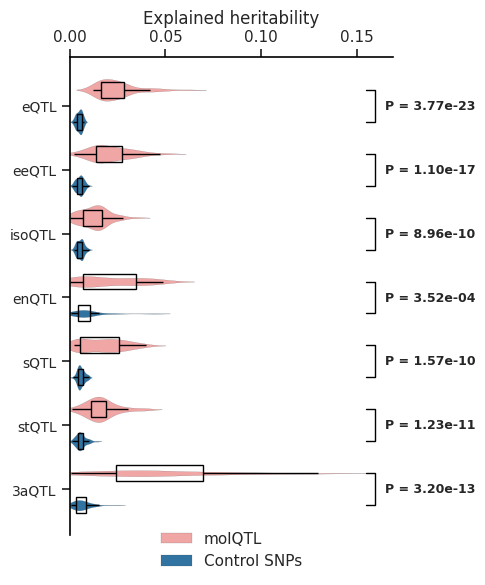

In [501]:
qtl_list = ['eQTL','eeQTL','isoQTL','enQTL','sQTL','stQTL','3aQTL']
order = []
for qtl_type in qtl_list:
    order.append(f"{qtl_type}_QTL")
    order.append(f"{qtl_type}_Matched")


palette = sns.color_palette("Paired") # 或 "husl","viridis", "muted", "pastel" 等
palette_dict = {"QTL": palette[4], "Matched": palette[1]}

plt.figure(figsize=(5, 6))  # 比较横向长的图

# 横向 violinplot
sns.violinplot(
    y="Group", x="Heritability", hue="Type",
    data=plot_df, inner=None, linewidth=0.1,
    palette=palette_dict, order=order, dodge=False, orient='h'
)

# 横向 boxplot
sns.boxplot(
    y="Group", x="Heritability", hue="Type",
    data=plot_df, showcaps=False, showfliers=False,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},
    whiskerprops={'color': 'black'},
    medianprops={'color': 'red', 'linewidth': 0},
    width=0.5, order=order, dodge=False, orient='h'
)

# 自定义图例
handles, labels = plt.gca().get_legend_handles_labels()
custom_labels = {"QTL": "molQTL", "Matched": "Control SNPs"}
new_labels = [custom_labels.get(label, label) for label in labels]
plt.legend(handles=handles[:2], labels=new_labels[:2], bbox_to_anchor=(0.5, -0.1), loc="lower center", frameon=False)

# 添加 p 值标注（沿 x 方向）
x_max = plot_df["Heritability"].max()
pval_x = x_max + 0.03

for i, (qtl_type, pval) in enumerate(pval_annotations):
    ypos1 = order.index(f"{qtl_type}_QTL")
    ypos2 = order.index(f"{qtl_type}_Matched")
    y_center = (ypos1 + ypos2) / 2
    plt.plot([pval_x - 0.005, pval_x, pval_x, pval_x - 0.005],
             [ypos1, ypos1, ypos2, ypos2],
             color="black", linewidth=1)
    plt.text(pval_x + 0.005, y_center, f"P = {pval:.2e}",
             va="center")

# 设置 Y 轴为 QTL 类型标签（中间位置）
yticks_pos = [(order.index(f"{qtl}_QTL") + order.index(f"{qtl}_Matched")) / 2 for qtl in filtered_df["QTL_Type"].unique()]
yticks_labels = [label.split('.')[-1] for label in filtered_df["QTL_Type"].unique()]
plt.yticks(yticks_pos, yticks_labels, fontsize=10)

x_ticks = np.arange(0, plot_df["Heritability"].max() + 0.05, 0.05)
plt.xticks(x_ticks)

plt.grid(False) 
# 标题和标签
plt.xlabel("Explained heritability")
plt.ylabel("")

# 只保留左边和上边坐标轴
ax = plt.gca()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

for spine in ["left", "top"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("black")
    ax.spines[spine].set_linewidth(1.2)

ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)



plt.xlim(0, None)
# plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("pdf/heritability_violinplot.pdf", dpi=300, bbox_inches='tight')  # 保存为 PDF 格式，高分辨率

# Fig. 7b

In [228]:
loci_df1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/gwas_qtl_pairs.tsv', sep="\t")
loci_df2 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/gwas_qtl_pairs_xinjiang.tsv', sep="\t")
loci_df = pd.concat([loci_df1, loci_df2])
loci_df['Trait'] = loci_df['TRAIT'].str.extract(r'filtered_STDERR_(.*)1$')
loci_df['Loci'] = loci_df['Trait'] + '|' + loci_df['LEAD_VARIANT']
loci_df["gene_symbol"] = [normalize_feature_id(qtl, feat) for qtl, feat in zip(loci_df["QTL_type"], loci_df["phenotype_id"])]

,TRAIT,LEAD_VARIANT,tissue,phenotype_id,variant_id,QTL_type,Trait,Loci,gene_symbol
0,filtered_STDERR_TL1,3_95147189,Muscle,RAB11FIP5,3_95145282,eQTL,TL,TL|3_95147189,RAB11FIP5
1,filtered_STDERR_TL1,3_95147189,Muscle,RAB11FIP5,3_95145377,eQTL,TL,TL|3_95147189,RAB11FIP5
2,filtered_STDERR_TL1,3_95147189,Muscle,RAB11FIP5,3_95145486,eQTL,TL,TL|3_95147189,RAB11FIP5
3,filtered_STDERR_TL1,3_95147189,Muscle,RAB11FIP5,3_95145511,eQTL,TL,TL|3_95147189,RAB11FIP5
4,filtered_STDERR_TL1,3_95147189,Muscle,RAB11FIP5,3_95145516,eQTL,TL,TL|3_95147189,RAB11FIP5
...,...,...,...,...,...,...,...,...,...
483418,filtered_STDERR_CUR1,21_26705695,Caul_adipose,LOC121817566:enhancer_chr21:27003600:27005400,21_27023628,enQTL,CUR,CUR|21_26705695,LOC121817566
483419,filtered_STDERR_CUR1,21_26705695,Caul_adipose,LOC121817566:enhancer_chr21:27003600:27005400,21_27023747,enQTL,CUR,CUR|21_26705695,LOC121817566
483420,filtered_STDERR_CUR1,21_26705695,Caul_adipose,LOC121817566:enhancer_chr21:27003600:27005400,21_27024089,enQTL,CUR,CUR|21_26705695,LOC121817566
483421,filtered_STDERR_CUR1,21_26705695,Embryo,LOC101117978:enhancer_chr21:26644800:26646600,21_27065789,enQTL,CUR,CUR|21_26705695,LOC101117978


In [232]:
coloc_df1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/coloc_new/GWAS.all.addcol.pph4.new', sep='\t')
coloc_df2 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/coloc_xinjiang/GWAS.all.addcol.pph4.new', sep='\t')
coloc_df = pd.concat([coloc_df1, coloc_df2]).dropna()
coloc_df = coloc_df.rename(columns={'qtl':'QTL_type', 'trait':'Trait', 'SNP':'LEAD_VARIANT', 'phenotype':'phenotype_id'})
coloc_df['Loci'] = coloc_df['Trait'] + '|' + coloc_df['LEAD_VARIANT']
coloc_df["gene_symbol"] = [normalize_feature_id(qtl, feat) for qtl, feat in zip(coloc_df["QTL_type"], coloc_df["phenotype_id"])]
#coloc_df.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/webdata/gwas_coloc/GWAS.all.addcol.coloc.csv.gz', index=None)

In [233]:
coloc_df_sig1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/coloc_new/GWAS.all.addcol.sig.pph4.new', sep='\t')
coloc_df_sig2 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/coloc_xinjiang/GWAS.all.addcol.sig.pph4.new', sep='\t')
coloc_df_sig = pd.concat([coloc_df_sig1, coloc_df_sig2]).dropna()
coloc_df_sig = coloc_df_sig.rename(columns={'qtl':'QTL_type', 'trait':'Trait', 'SNP':'LEAD_VARIANT', 'phenotype':'phenotype_id'})
coloc_df_sig['Loci'] = coloc_df_sig['Trait'] + '|' + coloc_df_sig['LEAD_VARIANT']
coloc_df_sig["gene_symbol"] = [normalize_feature_id(qtl, feat) for qtl, feat in zip(coloc_df_sig["QTL_type"], coloc_df_sig["phenotype_id"])]
#coloc_df_sig.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/webdata/gwas_coloc/GWAS.all.addcol.molGene.coloc.csv.gz', index=None)

In [553]:
coloc_loci_df_sig = pd.merge(coloc_df_sig, loci_df.drop(columns='variant_id').drop_duplicates(), how='right', on=['LEAD_VARIANT', 'tissue', 'phenotype_id', 'QTL_type', 'Trait', 'Loci', 'gene_symbol']).dropna()
coloc_loci_df_sig

,QTL_type,Trait,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,LEAD_VARIANT,phenotype_id,chrom,tissue,Loci,gene_symbol,TRAIT
5,eQTL,TL,107.0,0.036245,0.001121,0.786227,0.024154,0.152254,7_16926988,TLE3,chr7,Liver,TL|7_16926988,TLE3,filtered_STDERR_TL1
6,eQTL,TL,104.0,0.692403,0.021262,0.237625,0.007256,0.041455,7_16926988,TLE3,chr7,Adipose,TL|7_16926988,TLE3,filtered_STDERR_TL1
7,eQTL,TL,104.0,0.000251,0.000008,0.817931,0.024960,0.156850,7_16926988,TLE3,chr7,Small_intestine,TL|7_16926988,TLE3,filtered_STDERR_TL1
8,eQTL,TL,110.0,0.416921,0.013060,0.460041,0.014315,0.095663,7_16926988,TLE3,chr7,Abomasum,TL|7_16926988,TLE3,filtered_STDERR_TL1
9,eQTL,TL,100.0,0.643351,0.019404,0.278928,0.008363,0.049954,7_16926988,TLE3,chr7,Large_intestine,TL|7_16926988,TLE3,filtered_STDERR_TL1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31172,enQTL,CUR,1763.0,0.002562,0.001501,0.608341,0.356223,0.031372,21_26705695,RPUSD4:enhancer_chr21:27008600:27009800,chr21,Lymph_node,CUR|21_26705695,RPUSD4,filtered_STDERR_CUR1
31173,enQTL,CUR,1688.0,0.000110,0.000064,0.623717,0.363580,0.012529,21_26705695,LOC121817566:enhancer_chr21:27003600:27005400,chr21,Intermuscular_adipose,CUR|21_26705695,LOC121817566,filtered_STDERR_CUR1
31174,enQTL,CUR,1688.0,0.102874,0.059970,0.516929,0.301322,0.018904,21_26705695,RPUSD4:enhancer_chr21:27008600:27009800,chr21,Intermuscular_adipose,CUR|21_26705695,RPUSD4,filtered_STDERR_CUR1
31175,enQTL,CUR,1725.0,0.068613,0.040059,0.550565,0.321422,0.019341,21_26705695,LOC121817566:enhancer_chr21:27003600:27005400,chr21,Caul_adipose,CUR|21_26705695,LOC121817566,filtered_STDERR_CUR1


In [279]:
output_dir = Path("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc.gtex/upset")

In [280]:
# overlap
rows: list[dict[str, object]] = []
for loci, group_df in coloc_loci_df_sig.groupby("Loci"):
    trait = group_df['Trait'].unique()[0]
    tags = {"GWAS"}
    for qtl in ['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL']:
        if len(group_df[(group_df['PP.H4.abf']>0.8)&(group_df['QTL_type']==qtl)])>0:
            tags.add(qtl)

    rows.append({"loci": loci, "trait": trait, "tags": "|".join(sorted(tags)), "membership": tuple(sorted(tags))})

overlap_df = pd.DataFrame(rows)
overlap_df = overlap_df.sort_values(["trait", "loci"], kind="stable")
overlap_df.to_csv(output_dir / "gwas_coloc_overlap_tags.tsv", sep="\t", index=False)

/tmp/ipykernel_1837/4257482060.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


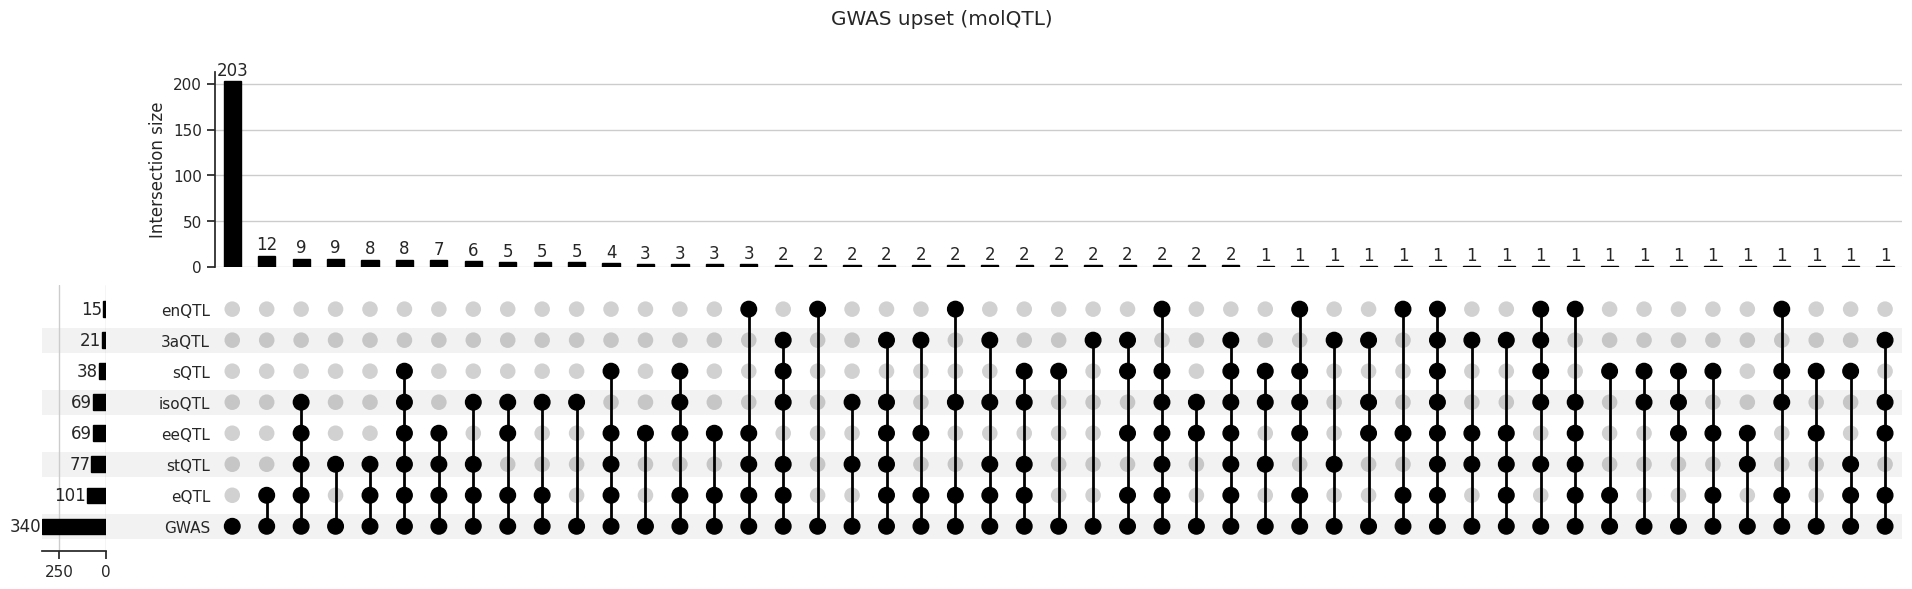

In [281]:
memberships = [tuple(v) for v in overlap_df["membership"].tolist()]
upset_data = from_memberships(memberships)
#upset_data = upset_data.sort_values(ascending=False).head(45)

fig = plt.figure(figsize=(12, 7))

upset = UpSet(upset_data, show_counts=True, subset_size="count", sort_by="cardinality")
upset.plot(fig=fig)
fig.suptitle("GWAS upset (molQTL)")
fig.tight_layout()
fig.savefig(output_dir / "gwas_coloc_overlap_tags.pdf", bbox_inches="tight")

# Fig. 7c

In [ ]:
egene_counts = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split/egenes.txt', sep='\t')
output_dir = Path("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc.gtex/upset")

In [402]:
coloc_counts = coloc_df_sig[(coloc_df_sig['PP.H4.abf']>0.8)].groupby(["Trait", "tissue"])['gene_symbol'].nunique().reset_index(name="coloc_count")
coloc_counts = pd.merge(trait_info, coloc_counts, left_on='Abbr. trait names', right_on='Trait')
coloc_counts = pd.merge(coloc_counts, dftis, how='left', left_on='tissue', right_on='Tissue')
coloc_counts = pd.merge(coloc_counts, egene_counts, how='left', on='Tissue')
#coloc_counts['Tissue relevance score'] = coloc_counts['coloc_count'] / (coloc_counts['Proportion of eGenes'] * coloc_counts['Sample size'])
coloc_counts['Tissue relevance score'] = coloc_counts['coloc_count'] / (coloc_counts['Sample size'])
coloc_counts['Tissue'] = coloc_counts['Tissue'].replace('_', ' ', regex=True)
coloc_counts["Rank"] = (coloc_counts.groupby("Trait")["Tissue relevance score"].rank(method="first", ascending=False).astype(int))
coloc_counts = coloc_counts.sort_values(["Trait", "Rank"])
coloc_counts[['Full trait names', 'Abbr. trait names', 'Category', 'Tissue', 'Tissue relevance score', 'Rank']].to_csv(output_dir / 'tissue_relevance.txt', index=None, sep='\t')

In [395]:
coloc_counts[coloc_counts['Rank']<4]['tissue'].value_counts().head()

tissue
Adenohypophysis       10
Uterus                 8
Cervix                 7
Liver                  6
Longissimus_muscle     6
Name: count, dtype: int64

In [401]:
coloc_counts[(coloc_counts['Rank']<4)&(coloc_counts['Tissue']=="Adenohypophysis")]

,Full trait names,Abbr. trait names,Category,Trait,tissue,coloc_count,Tissue,Sample size,PEER,Number of eGenes,Number of tested genes,Proportion of eGenes,Tissue relevance score,Rank
305,Brightness Index,BRIN,Wool,BRIN,Adenohypophysis,4,Adenohypophysis,116,15,4465,19646,0.227273,0.034483,1
79,Cannon Bone Circumference,CBC,Body Size,CBC,Adenohypophysis,4,Adenohypophysis,116,15,4465,19646,0.227273,0.034483,1
161,Ear Length,EL,Facial,EL,Adenohypophysis,3,Adenohypophysis,116,15,4465,19646,0.227273,0.025862,2
191,Ear Width,EW,Facial,EW,Adenohypophysis,3,Adenohypophysis,116,15,4465,19646,0.227273,0.025862,3
117,Hip Width,HW,Body Size,HW,Adenohypophysis,1,Adenohypophysis,116,15,4465,19646,0.227273,0.008621,3
288,Multiple Litter Sample,MLS,Reproduction,MLS,Adenohypophysis,4,Adenohypophysis,116,15,4465,19646,0.227273,0.034483,2
425,Original (or Greasy) Wool Weight,OHW,Wool,OHW,Adenohypophysis,3,Adenohypophysis,116,15,4465,19646,0.227273,0.025862,1
515,Wool Crimp Length / Wool Staple Length,WCL,Wool,WCL,Adenohypophysis,2,Adenohypophysis,116,15,4465,19646,0.227273,0.017241,2
536,Whiteness Index,WHTN,Wool,WHTN,Adenohypophysis,4,Adenohypophysis,116,15,4465,19646,0.227273,0.034483,1
383,Mean Fiber Diameter,meanD,Wool,meanD,Adenohypophysis,2,Adenohypophysis,116,15,4465,19646,0.227273,0.017241,3


In [431]:
trait_categories = {
    "Body Size": ["BH", "BL", "BW", "CBC", "CD", "CW", "HW"],
    "Facial": ["NW", "ML", "EL", "EW"],
    "Reproduction": ["MLS"],
    "Wool": ["BRIN", "OHW", "WCL", "WHTN", "meanD", "OSR"]
}
trait_to_category = {trait: cat for cat, traits in trait_categories.items() for trait in traits}
df = coloc_counts[coloc_counts['Abbr. trait names'].isin(trait_to_category)]

# top N tissues per trait
top_n = 3
top_df = df.sort_values(["Category", "Abbr. trait names", "Tissue relevance score"], ascending=[True, True, False]).groupby("Abbr. trait names").head(top_n)

# sort by max tissue relevance score
trait_max = top_df.groupby(["Abbr. trait names"])["Tissue relevance score"].max().reset_index()
trait_max["Category"] = trait_max["Abbr. trait names"].map(trait_to_category)
trait_max = trait_max.sort_values(["Category", "Tissue relevance score"], ascending=[True, True])
trait_order = trait_max["Abbr. trait names"].tolist()[::-1]
top_df["Trait"] = pd.Categorical(top_df["Abbr. trait names"], categories=trait_order, ordered=True)

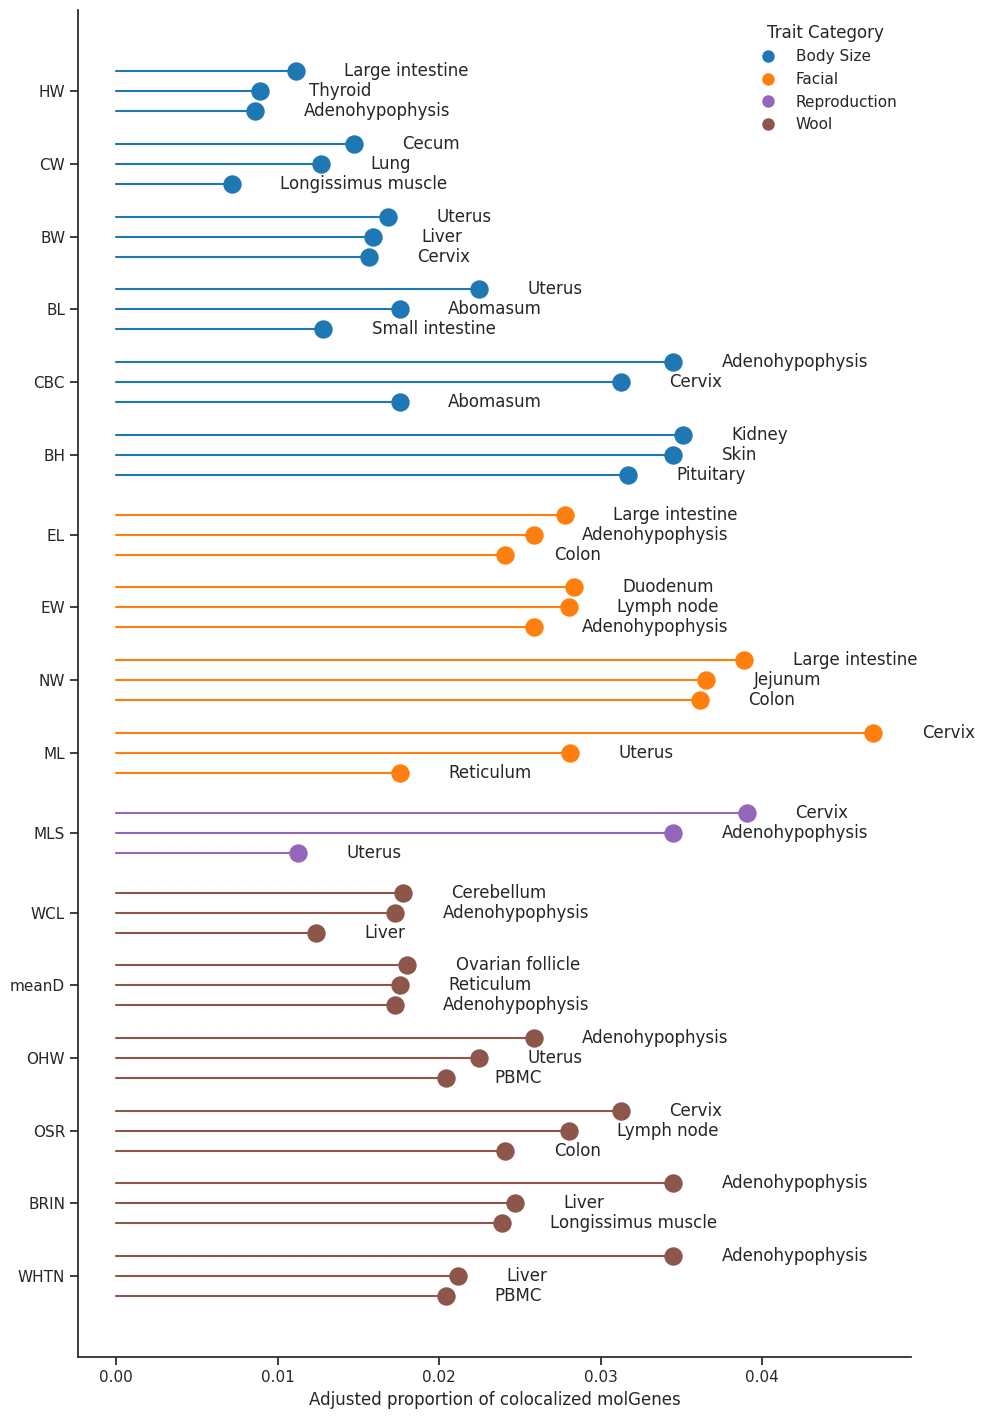

In [437]:
gap_within_category = 2       # trait之间（同一大类）纵向间距
gap_between_categories = 2.2        # trait大类之间额外间距
offset_spacing = 0.55              # 同一trait内不同组织点之间的纵向间距
label_x_offset = 0.003            # 标签文字距离点的水平距离

# 5. 构建 trait 对应的 y 轴坐标，加入大类间距
trait_to_y = {}
y = 0
prev_cat = None
for trait in trait_order:
    curr_cat = trait_to_category.get(trait)
    if prev_cat is not None and curr_cat != prev_cat:
        y += gap_between_categories  # 不同大类间隔
    else:
        y += gap_within_category     # 同一大类间隔
    trait_to_y[trait] = y
    prev_cat = curr_cat

# 6. 设置颜色
category_palette = {"Body Size": "#1f77b4", "Facial": "#ff7f0e", "Reproduction": "#9467bd", "Wool": "#8c564b"}
top_df["Color"] = top_df["Category"].map(category_palette)

# 7. 绘图
plt.figure(figsize=(10, 0.55 * len(trait_order) + 5))

# 计算每个 trait 内部组织点的纵向偏移量，等距分布
offsets = np.linspace(-offset_spacing * (top_n - 1) / 2, offset_spacing * (top_n - 1) / 2, top_n)

for trait in trait_order:
    y_base = trait_to_y[trait]
    trait_rows = top_df[top_df["Abbr. trait names"] == trait].sort_values("Tissue relevance score", ascending=True)
    for j, (_, row) in enumerate(trait_rows.iterrows()):
        y = y_base + offsets[j]
        x = row["Tissue relevance score"]
        # 画线条和点
        plt.plot([0, x], [y, y], color=row["Color"], linewidth=1.5)
        plt.scatter(x, y, s=150, color=row["Color"], zorder=3)
        # 画标签，x 轴方向偏移 label_x_offset 控制距离
        plt.text(x + label_x_offset, y, row["Tissue"], ha="left", va="center")

# 8. 设置 y 轴刻度和标签
yticks = [trait_to_y[t] for t in trait_order]
yticklabels = trait_order
plt.yticks(yticks, yticklabels)

plt.xlabel("Adjusted proportion of colocalized molGenes")
# plt.ylabel("Trait")
sns.despine()

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.tick_params(axis='x', which='both', direction='in', length=6, pad=7)

plt.grid(False)
plt.tight_layout()


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cat,
           markerfacecolor=color, markersize=10)
    for cat, color in category_palette.items()
]

plt.legend(
    handles=legend_elements,
    title="Trait Category",
    loc='upper right',  # 可选 'upper right'、'center left' 等
    frameon=False
)
plt.savefig("pdf/top_coloc_horizontal.pdf", bbox_inches='tight')

# Fig. 7d-f

In [17]:
coloc_df = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/webdata/gwas_coloc/GWAS.all.addcol.coloc.csv.gz')
coloc_df

,QTL_type,Trait,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,LEAD_VARIANT,phenotype_id,chrom,tissue,Loci,gene_symbol
0,3aQTL,BH,1,0.748965,0.239300,0.000037,0.000000,0.011699,1_191568838,XM_042232553.1|ZNF148|chr1|-,chr1,Muscle,BH|1_191568838,ZNF148
1,3aQTL,BH,1,0.746429,0.238490,0.000047,0.000000,0.015034,1_191568838,XM_042232590.1|SNX4|chr1|-,chr1,Muscle,BH|1_191568838,SNX4
2,3aQTL,BH,1,0.749190,0.239372,0.000036,0.000000,0.011402,1_191568838,XM_042232591.1|OSBPL11|chr1|-,chr1,Muscle,BH|1_191568838,OSBPL11
3,3aQTL,BH,1,0.741604,0.236948,0.000067,0.000000,0.021381,1_191568838,XM_027956731.2|LRCH3|chr1|-,chr1,Muscle,BH|1_191568838,LRCH3
4,3aQTL,BH,1,0.748840,0.239260,0.000037,0.000000,0.011862,1_191568838,XM_004003000.5|FYTTD1|chr1|-,chr1,Muscle,BH|1_191568838,FYTTD1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265841,stQTL,YELN,165,0.957116,0.020204,0.020075,0.000422,0.002183,20_30850199,TRIM38,chr20,Oviduct,YELN|20_30850199,TRIM38
4265842,stQTL,YELN,165,0.955998,0.020180,0.021201,0.000445,0.002176,20_30850199,LOC114109525,chr20,Oviduct,YELN|20_30850199,LOC114109525
4265843,stQTL,YELN,165,0.962562,0.020319,0.014852,0.000312,0.001955,20_30850199,CARMIL1,chr20,Oviduct,YELN|20_30850199,CARMIL1
4265844,stQTL,YELN,165,0.960692,0.020279,0.016663,0.000350,0.002016,20_30850199,LOC101106806,chr20,Oviduct,YELN|20_30850199,LOC101106806


In [9]:
df_rsid = pd.read_csv('/storage/public/home/2020060185/genome/sheep/refpanel/snpid2rsid.txt.gz', sep='\t')
qtl_list = ['eQTL','eeQTL','isoQTL','enQTL','sQTL','stQTL','3aQTL']
pathe = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
path3a = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/06.3aQTL"

In [30]:
def load_ld(plink_prefix, ld_prefix, variant_id):
    ## input bim file
    bim_file = f'{plink_prefix}.bim'
    bim_df = pd.read_csv(bim_file, delim_whitespace=True, header=None,
                         names=['CHR', 'variant_id', 'CM', 'BP', 'ALT', 'REF'])
    
    if variant_id in bim_df['variant_id'].values:
        # compute LD
        if not os.path.isfile(f'{ld_prefix}.ld.gz'):
            cmd=f'''/storage/public/home/2020060185/bin/plink \\
                --bfile {plink_prefix} --ld-snp {variant_id} \\
                --sheep --keep-allele-order --r2 gz yes-really \\
                --ld-window-kb 999999 --ld-window 999999 --ld-window-r2 0 \\
                --out {ld_prefix}'''
            os.system(cmd)
            # os.remove(f'{ld_prefix}.nosex')
            # os.remove(f'{ld_prefix}.log')
        else:
            print(f"file exist: {ld_prefix}.ld.gz")
        ld_df = pd.read_csv(f'{ld_prefix}.ld.gz', delim_whitespace=True)
        ld_df = ld_df[['SNP_B', 'R2']]
        ld_df.columns = ['variant_id', 'R2']
        
        ## merge data
        ld_df = pd.merge(bim_df, ld_df, on='variant_id')
        return ld_df
    else:
        warnings.warn(f"{variant_id} is not exist in bim file!")
        return pd.DataFrame()
        

In [218]:
def combined_gwas_qtl_locusplot(gwas_df, qtl_df, qtl_list=None, variant_id=None,
                                rsid=None, coloc=None, width=3, height=2.5, caxw=None, caxh=None,
                                orientation='vertical', show_colorbar=False):

    sns.set_theme(style="ticks")
    # ========== 基本信息 ==========
    trait = coloc['Trait'].values[0]
    gene = coloc['gene_symbol'].values[0]
    tissue = coloc['tissue'].values[0]
    chrom = coloc['chrom'].values[0]
    if qtl_list is None:
        qtl_list = qtl_df['QTL'].unique()
    valid_qtls = [qtl for qtl in qtl_list if not coloc[coloc['QTL_type'] == qtl].empty]
    n_qtls = len(valid_qtls)
    n_plots = 1 + n_qtls  # 1 for GWAS

    # sorted by R2
    gwas_df = gwas_df.sort_values(by='R2', ascending=True)
    qtl_df = qtl_df.sort_values(by='R2', ascending=True)

    # ========== GWAS y 轴 ==========
    if '-log10P' not in gwas_df.columns:
        gwas_df['-log10P'] = -np.log10(gwas_df['p'])
    ymax_gwas = gwas_df['-log10P'].max() * 1.05

    # ========== QTL y 轴（统一所有 QTL） ==========
    if '-log10P' not in qtl_df.columns:
        qtl_df['-log10P'] = -np.log10(qtl_df['pval_nominal'])
    ymax_qtl = qtl_df['-log10P'].max() * 1.05

    # ========== 色图 ==========
    lz_colors = ["#282973", "#8CCCF0", "#69BD45", "#F9A41A", "#ED1F24"]
    cmap = mpl.colors.ListedColormap(lz_colors)
    bounds = np.arange(0, 1.2, 0.2)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

    # ========== 图形布局 ==========
    if orientation == 'vertical':
        figsize = (width, height * n_plots)
        fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=figsize, sharex=True, sharey=False)
        if show_colorbar:
            if not (caxw and caxh):
                caxw, caxh = 0.015 * height, 0.25 * height
            cax = fig.add_axes([0.91, 0.5, caxw, caxh])
    elif orientation == 'horizontal':
        height_h = max(height, 2.5)
        figsize = (width * n_plots, height_h)
        fig, axes = plt.subplots(nrows=1, ncols=n_plots, figsize=figsize, sharex=True, sharey=True)
        if show_colorbar:
            if not (caxw and caxh):
                caxw, caxh = 0.012 * width, 0.6 * height_h
            cax = fig.add_axes([0.91, 0.3, caxw, caxh])
    else:
        raise ValueError("orientation must be 'vertical' or 'horizontal'")

    if n_plots == 1:
        axes = [axes]

    # ========== 色条 ==========
    if show_colorbar:
        cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, boundaries=bounds, ticks=bounds,
                                       spacing='proportional', orientation='vertical')
        cax.set_title('LD (r2)')
        cax.tick_params()

    # ========== Panel 1: GWAS ==========
    ax = axes[0]
    ax.set_title(f"GWAS {trait}")
    sc = ax.scatter(gwas_df['bp'] / 1e6, gwas_df['-log10P'], c=gwas_df['R2'], cmap=cmap, norm=norm, s=10, edgecolor=None)
    sc.set_rasterized(True)

    snp = variant_id if (variant_id and variant_id in gwas_df['variant_id'].values) \
                     else gwas_df.loc[gwas_df['p'].idxmin()]['variant_id']
    snp_bp = gwas_df[gwas_df['variant_id'] == snp]['bp'].values[0]
    snp_p = gwas_df[gwas_df['variant_id'] == snp]['-log10P'].values[0]
    label = rsid if rsid else snp
    ax.scatter(snp_bp / 1e6, snp_p, color='purple', marker='D', s=50, edgecolor='black')
    ax.text(snp_bp / 1e6 * 1.001, snp_p * 1.001, label, ha="center", va="bottom")
    ax.set_ylabel("-log10P")
    ax.set_ylim([0, ymax_gwas])

    # ========== Panel 2+: QTL ==========
    for i, qtl in enumerate(valid_qtls):
        ax = axes[i + 1]
        if i == 0:
            ax.set_title(f'{gene} in {tissue}')
        phenotype_id = coloc.loc[coloc['QTL_type']==qtl, 'phenotype_id'].values[0]
        plot_df = qtl_df[(qtl_df['QTL']==qtl)&(qtl_df['phenotype_id']==phenotype_id)]
        sc = ax.scatter(plot_df['BP'] / 1e6, plot_df['-log10P'], c=plot_df['R2'],
                        cmap=cmap, norm=norm, s=10, edgecolor=None)
        sc.set_rasterized(True)

        # 阈值线
        if 'pval_nominal_threshold' in plot_df.columns:
            pval_nominal_threshold = plot_df['pval_nominal_threshold'].iloc[0]
            ax.axhline(y=-np.log10(pval_nominal_threshold), color='red', linestyle='--')

        # 标记SNP
        snp = variant_id if (variant_id and variant_id in plot_df['variant_id'].values) \
              else plot_df.loc[plot_df['pval_nominal'].idxmin()]['variant_id']
        snp_bp = plot_df[plot_df['variant_id'] == snp]['BP'].values[0]
        snp_p = plot_df[plot_df['variant_id'] == snp]['-log10P'].values[0]
        label = rsid if rsid else snp
        ax.scatter(snp_bp / 1e6, snp_p, color='purple', marker='D', s=50, edgecolor='black')
        ax.text(snp_bp / 1e6 * 1.001, snp_p * 1.001, label, ha="center", va="bottom")

        # 注释
        pph4 = coloc.loc[coloc['QTL_type']==qtl, 'PP.H4.abf'].values[0]
        annot = f"{qtl}\n" + "PPH4 = " + (f"{pph4:.2f}" if not np.isnan(pph4) else "NA")
        xmin = ax.get_xlim()[0]
        ax.text(xmin * 1.001, ymax_qtl, annot, ha="left", va="top")

        ax.set_ylabel("-log10P")
        ax.set_ylim([0, ymax_qtl])  # 所有 QTL 统一
    ax.set_xlabel(f"{chrom} (Mb)")

    fig.subplots_adjust(hspace=0.25 if orientation == 'vertical' else 0.3,
                        wspace=0.25 if orientation == 'horizontal' else 0.1)
    plt.tight_layout()
    sns.despine()
    
    return fig


## example1

In [135]:
trait = "CBC"
gene = "CATSPERD"
tissue = "Adenohypophysis"
variant_id = "5_16429042"
chrom = variant_id.split('_')[0]
rsid = df_rsid.loc[df_rsid['variant_id']==variant_id, 'rsid'].values[0]
plot_df = coloc_df.loc[coloc_df[(coloc_df['Trait']==trait)&(coloc_df['gene_symbol']==gene)&(coloc_df['tissue']==tissue)&(coloc_df['LEAD_VARIANT']==variant_id)].groupby('QTL_type')['PP.H4.abf'].idxmax()]
plot_df

,QTL_type,Trait,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,LEAD_VARIANT,phenotype_id,chrom,tissue,Loci,gene_symbol
1776499,eQTL,CBC,274,8.194419e-12,2.802207e-10,0.000639,0.020868,0.978493,5_16429042,CATSPERD,chr5,Adenohypophysis,CBC|5_16429042,CATSPERD
1775560,eeQTL,CBC,274,3.318577e-03,1.134838e-01,0.005674,0.193332,0.684192,5_16429042,CATSPERD:chr5:16428991:16429552,chr5,Adenohypophysis,CBC|5_16429042,CATSPERD
1778591,sQTL,CBC,274,2.322884e-02,7.943457e-01,0.000773,0.026281,0.155371,5_16429042,chr5:16423108:16425038:clu_309075_+:CATSPERD,chr5,Adenohypophysis,CBC|5_16429042,CATSPERD
1779917,stQTL,CBC,274,1.965050e-02,6.719787e-01,0.001214,0.041264,0.265892,5_16429042,CATSPERD,chr5,Adenohypophysis,CBC|5_16429042,CATSPERD


In [136]:
# load gwas data
gwas_df = pd.read_csv(f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc.gtex/coloc/{trait}/{trait}.tbl.txt', sep='\t')
# GWAS LD
plink_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/fastEnloc/01.Match_LD_block/LD_map/bfile/chr{chrom}"
ld_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/{variant_id}"
gwas_ld_df = load_ld(plink_prefix=plink_prefix, ld_prefix=ld_prefix, variant_id=variant_id)
# merge
gwas_df_sub = pd.merge(gwas_df, gwas_ld_df[['variant_id','R2']], left_on='SNP', right_on='variant_id')

file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/5_16429042.ld.gz


In [137]:
# load QTL data
qtl_df = pd.DataFrame()
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
for qtl in qtl_list:
    if qtl in plot_df['QTL_type'].values:
        print(qtl)
        phenotype_id = plot_df.loc[plot_df['QTL_type']==qtl, 'phenotype_id'].values[0]
        pph4 =  plot_df.loc[plot_df['QTL_type']==qtl, 'PP.H4.abf'].values[0]
        
        # get LD information of the top SNP of each type of molQTL
        os.makedirs(f'{path}/{tissue}/local/locuszoom/{gene}', exist_ok=True)
        if qtl=='3aQTL':
            plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.3a'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        else:
            plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.e'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        if df_ld.empty:
            warnings.warn(f"{variant_id} does not exist in {tissue} {gene} {qtl}.")
            continue
        
        # get QTL information
        dfp = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t')
        pval_nominal_threshold = dfp.loc[dfp['phenotype_id']==gene, 'pval_nominal_threshold'].values[0]
        dfn = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.chr{chrom}.txt.gz', sep='\t')
        qtl_df_ = dfn[dfn['phenotype_id']==phenotype_id]
        qtl_df_ = qtl_df_.dropna(subset=['pval_nominal'])
        if qtl_df_.empty:
            warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
            continue
        qtl_df_['pval_nominal_threshold'] = pval_nominal_threshold
        qtl_df_['PP.H4.abf'] = pph4
        qtl_df_['QTL'] = qtl
        
        ## merge data
        qtl_df_ = pd.merge(qtl_df_, df_ld, on='variant_id', how='left')
        qtl_df = pd.concat([qtl_df, qtl_df_])

#shutil.rmtree(f'{path}/{tissue}/local/locuszoom/{gene}')
gwas_df_plot = gwas_df_sub[(gwas_df_sub['bp']>=qtl_df['BP'].min())&(gwas_df_sub['bp']<=qtl_df['BP'].max())]

eQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/CATSPERD/CATSPERD.5_16429042.e.ld.gz
eeQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/CATSPERD/CATSPERD.5_16429042.e.ld.gz
sQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/CATSPERD/CATSPERD.5_16429042.e.ld.gz
stQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/CATSPERD/CATSPERD.5_16429042.e.ld.gz


In [ ]:
gwas_df_plot1 = gwas_df_plot.copy()
qtl_df1 = qtl_df.copy()
plot_df1 = plot_df.copy()

variant_id1 = variant_id
rsid1 = rsid
trait1 = trait
gene1 = gene
tissue1 = tissue

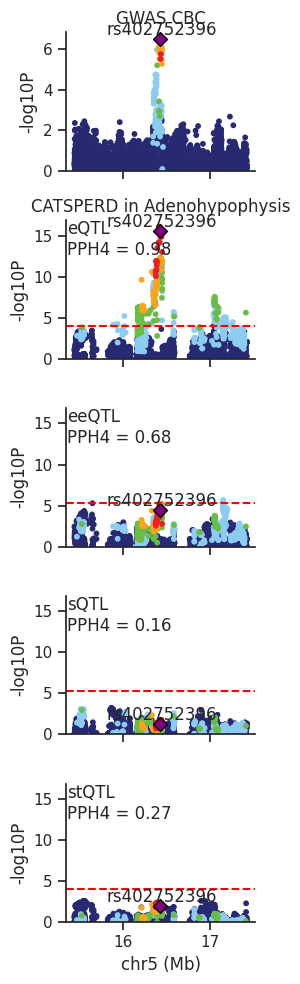

In [222]:
fig = combined_gwas_qtl_locusplot(gwas_df=gwas_df_plot1, qtl_df=qtl_df1, qtl_list=qtl_list, variant_id=variant_id1,
                                  rsid=rsid1, coloc=plot_df1, width=3, height=2, orientation='vertical', show_colorbar=False)
fig.savefig(f"pdf/{trait1}_{tissue1}_{gene1}_{variant_id1}_vertical.pdf", dpi=300, bbox_inches='tight')

## exmaple2

In [152]:
trait = "MLS"
gene = "FXYD1"
tissue = "Adenohypophysis"
variant_id = "14_45168578"
chrom = variant_id.split('_')[0]
rsid = df_rsid.loc[df_rsid['variant_id']==variant_id, 'rsid'].values[0]
plot_df = coloc_df.loc[coloc_df[(coloc_df['Trait']==trait)&(coloc_df['gene_symbol']==gene)&(coloc_df['tissue']==tissue)&(coloc_df['LEAD_VARIANT']==variant_id)].groupby('QTL_type')['PP.H4.abf'].idxmax()]
plot_df

,QTL_type,Trait,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,LEAD_VARIANT,phenotype_id,chrom,tissue,Loci,gene_symbol
1811231,3aQTL,MLS,122,0.797810,0.113913,0.019540,0.002724,0.066014,14_45168578,XM_012190164.3|FXYD1|chr14|+,chr14,Adenohypophysis,MLS|14_45168578,FXYD1
1813203,eQTL,MLS,122,0.832781,0.118906,0.023013,0.003264,0.022036,14_45168578,FXYD1,chr14,Adenohypophysis,MLS|14_45168578,FXYD1
1814218,isoQTL,MLS,122,0.001462,0.000209,0.043673,0.005286,0.949369,14_45168578,FXYD1:XM_042231979.1,chr14,Adenohypophysis,MLS|14_45168578,FXYD1
1816839,sQTL,MLS,122,0.612471,0.087450,0.191967,0.027329,0.080784,14_45168578,chr14:45154736:45155036:clu_78047_+:FXYD1,chr14,Adenohypophysis,MLS|14_45168578,FXYD1
1818183,stQTL,MLS,122,0.857440,0.122427,0.009702,0.001376,0.009055,14_45168578,FXYD1,chr14,Adenohypophysis,MLS|14_45168578,FXYD1


In [153]:
# load gwas data
gwas_df = pd.read_csv(f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc.gtex/coloc/{trait}/{trait}.tbl.txt', sep='\t')
# GWAS LD
plink_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/fastEnloc/01.Match_LD_block/LD_map/bfile/chr{chrom}"
ld_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/{variant_id}"
gwas_ld_df = load_ld(plink_prefix=plink_prefix, ld_prefix=ld_prefix, variant_id=variant_id)
# merge
gwas_df_sub = pd.merge(gwas_df, gwas_ld_df[['variant_id','R2']], left_on='SNP', right_on='variant_id')

file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/14_45168578.ld.gz


In [154]:
# load QTL data
qtl_df = pd.DataFrame()
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
for qtl in qtl_list:
    if qtl in plot_df['QTL_type'].values:
        print(qtl)
        phenotype_id = plot_df.loc[plot_df['QTL_type']==qtl, 'phenotype_id'].values[0]
        pph4 =  plot_df.loc[plot_df['QTL_type']==qtl, 'PP.H4.abf'].values[0]
        
        # get LD information of the top SNP of each type of molQTL
        os.makedirs(f'{path}/{tissue}/local/locuszoom/{gene}', exist_ok=True)
        if qtl=='3aQTL':
            plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.3a'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        else:
            plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.e'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        if df_ld.empty:
            warnings.warn(f"{variant_id} does not exist in {tissue} {gene} {qtl}.")
            continue
        
        # get QTL information
        dfp = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t')
        pval_nominal_threshold = dfp.loc[dfp['phenotype_id']==gene, 'pval_nominal_threshold'].values[0]
        dfn = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.chr{chrom}.txt.gz', sep='\t')
        qtl_df_ = dfn[dfn['phenotype_id']==phenotype_id]
        qtl_df_ = qtl_df_.dropna(subset=['pval_nominal'])
        if qtl_df_.empty:
            warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
            continue
        qtl_df_['pval_nominal_threshold'] = pval_nominal_threshold
        qtl_df_['PP.H4.abf'] = pph4
        qtl_df_['QTL'] = qtl
        
        ## merge data
        qtl_df_ = pd.merge(qtl_df_, df_ld, on='variant_id', how='left')
        qtl_df = pd.concat([qtl_df, qtl_df_])
        
#shutil.rmtree(f'{path}/{tissue}/local/locuszoom/{gene}')
gwas_df_plot = gwas_df_sub[(gwas_df_sub['bp']>=qtl_df['BP'].min())&(gwas_df_sub['bp']<=qtl_df['BP'].max())]

eQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/FXYD1/FXYD1.14_45168578.e.ld.gz
isoQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/FXYD1/FXYD1.14_45168578.e.ld.gz
sQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/FXYD1/FXYD1.14_45168578.e.ld.gz
stQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/FXYD1/FXYD1.14_45168578.e.ld.gz
3aQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Adenohypophysis/local/locuszoom/FXYD1/FXYD1.14_45168578.3a.ld.gz


In [ ]:
gwas_df_plot2 = gwas_df_plot.copy()
qtl_df2 = qtl_df.copy()
plot_df2 = plot_df.copy()

variant_id2 = variant_id
rsid2 = rsid
trait2 = trait
gene2 = gene
tissue2 = tissue

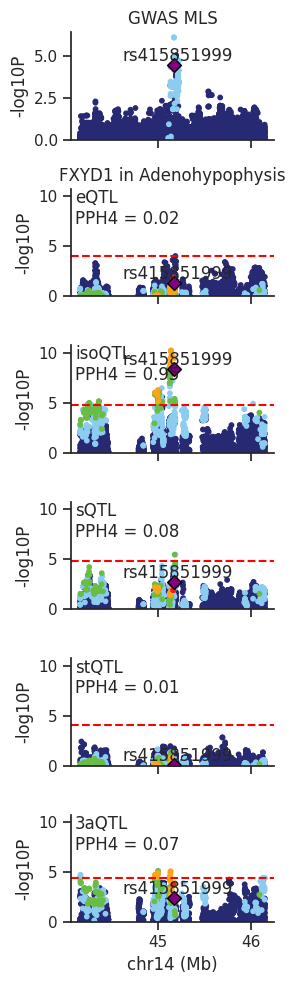

In [208]:
fig = combined_gwas_qtl_locusplot(gwas_df=gwas_df_plot2, qtl_df=qtl_df2, qtl_list=qtl_list, variant_id=variant_id2,
                                  rsid=rsid2, coloc=plot_df2, width=3, height=1.66667, orientation='vertical', show_colorbar=False)
fig.savefig(f"pdf/{trait2}_{tissue2}_{gene2}_{variant_id2}_vertical.pdf", dpi=300, bbox_inches='tight')

## example3

In [165]:
trait = "OSR"
gene = "COLGALT2"
tissue = "Liver"
variant_id = "12_64416129"
chrom = variant_id.split('_')[0]
rsid = df_rsid.loc[df_rsid['variant_id']==variant_id, 'rsid'].values[0]
plot_df = coloc_df.loc[coloc_df[(coloc_df['Trait']==trait)&(coloc_df['gene_symbol']==gene)&(coloc_df['tissue']==tissue)&(coloc_df['LEAD_VARIANT']==variant_id)].groupby('QTL_type')['PP.H4.abf'].idxmax()]
plot_df

,QTL_type,Trait,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,LEAD_VARIANT,phenotype_id,chrom,tissue,Loci,gene_symbol
3103906,3aQTL,OSR,1,0.000506,0.000778,0.000650,0.0,0.998066,12_64416129,XM_004013865.4|COLGALT2|chr12|-,chr12,Liver,OSR|12_64416129,COLGALT2
3104482,eQTL,OSR,1,0.358600,0.551023,0.000059,0.0,0.090318,12_64416129,COLGALT2,chr12,Liver,OSR|12_64416129,COLGALT2
3104124,eeQTL,OSR,1,0.289976,0.445575,0.000172,0.0,0.264277,12_64416129,COLGALT2:chr12:64412373:64415301,chr12,Liver,OSR|12_64416129,COLGALT2
3104924,stQTL,OSR,1,0.018152,0.027893,0.000620,0.0,0.953334,12_64416129,COLGALT2,chr12,Liver,OSR|12_64416129,COLGALT2


In [166]:
# load gwas data
gwas_df = pd.read_csv(f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc.gtex/coloc/{trait}/{trait}.tbl.txt', sep='\t')
# GWAS LD
plink_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/fastEnloc/01.Match_LD_block/LD_map/bfile/chr{chrom}"
ld_prefix = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/{variant_id}"
gwas_ld_df = load_ld(plink_prefix=plink_prefix, ld_prefix=ld_prefix, variant_id=variant_id)
# merge
gwas_df_sub = pd.merge(gwas_df, gwas_ld_df[['variant_id','R2']], left_on='SNP', right_on='variant_id')

file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/04.gwas_coloc/locuszoom_gwas_ld/12_64416129.ld.gz


In [167]:
# load QTL data
qtl_df = pd.DataFrame()
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
for qtl in qtl_list:
    if qtl in plot_df['QTL_type'].values:
        print(qtl)
        phenotype_id = plot_df.loc[plot_df['QTL_type']==qtl, 'phenotype_id'].values[0]
        pph4 =  plot_df.loc[plot_df['QTL_type']==qtl, 'PP.H4.abf'].values[0]
        
        # get LD information of the top SNP of each type of molQTL
        os.makedirs(f'{path}/{tissue}/local/locuszoom/{gene}', exist_ok=True)
        if qtl=='3aQTL':
            plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.3a'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        else:
            plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
            ld_prefix = f'{path}/{tissue}/local/locuszoom/{gene}/{gene}.{variant_id}.e'
            df_ld = load_ld(plink_prefix, ld_prefix, variant_id=variant_id)
        if df_ld.empty:
            warnings.warn(f"{variant_id} does not exist in {tissue} {gene} {qtl}.")
            continue
        
        # get QTL information
        dfp = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t')
        pval_nominal_threshold = dfp.loc[dfp['phenotype_id']==gene, 'pval_nominal_threshold'].values[0]
        dfn = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.chr{chrom}.txt.gz', sep='\t')
        qtl_df_ = dfn[dfn['phenotype_id']==phenotype_id]
        qtl_df_ = qtl_df_.dropna(subset=['pval_nominal'])
        if qtl_df_.empty:
            warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
            continue
        qtl_df_['pval_nominal_threshold'] = pval_nominal_threshold
        qtl_df_['PP.H4.abf'] = pph4
        qtl_df_['QTL'] = qtl
        
        ## merge data
        qtl_df_ = pd.merge(qtl_df_, df_ld, on='variant_id', how='left')
        qtl_df = pd.concat([qtl_df, qtl_df_])

#shutil.rmtree(f'{path}/{tissue}/local/locuszoom/{gene}')
gwas_df_plot = gwas_df_sub[(gwas_df_sub['bp']>=qtl_df['BP'].min())&(gwas_df_sub['bp']<=qtl_df['BP'].max())]

eQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Liver/local/locuszoom/COLGALT2/COLGALT2.12_64416129.e.ld.gz
eeQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Liver/local/locuszoom/COLGALT2/COLGALT2.12_64416129.e.ld.gz
stQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Liver/local/locuszoom/COLGALT2/COLGALT2.12_64416129.e.ld.gz
3aQTL
file exist: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Liver/local/locuszoom/COLGALT2/COLGALT2.12_64416129.3a.ld.gz


In [171]:
gwas_df_plot3 = gwas_df_plot.copy()
qtl_df3 = qtl_df.copy()
plot_df3 = plot_df.copy()

variant_id3 = variant_id
rsid3 = rsid
trait3 = trait
gene3 = gene
tissue3 = tissue

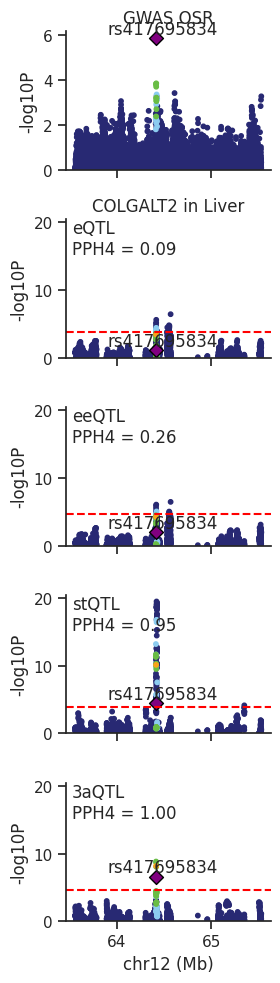

In [209]:
fig = combined_gwas_qtl_locusplot(gwas_df=gwas_df_plot3, qtl_df=qtl_df3, qtl_list=qtl_list, variant_id=variant_id3,
                                  rsid=rsid3, coloc=plot_df3, width=3, height=2, orientation='vertical', show_colorbar=False)
fig.savefig(f"pdf/{trait3}_{tissue3}_{gene3}_{variant_id3}_vertical.pdf", dpi=300, bbox_inches='tight')